# Session IX — Loss functions & output heads

**One notebook, one loss harness.** Class spine:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss = cross_entropy(
    logits[:, :-1].reshape(-1, vocab_size),
    tokens[:, 1:].reshape(-1),
)
```

Sample model: tiny GPT (2 layers, char tokenizer). Or run `python run_harness.py` for the same checks plus `artifacts/results.json`.



## Setup



In [1]:
import math, random, json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from loss_harness import (
    CharTokenizer, GPTConfig, TinyGPT,
    labels_with_pad_ignored, pad_batch, pack_two_docs,
    shift_ce_loss, perplexity_from_loss, count_params,
    measure_ce_memory, mtp_losses,
)

random.seed(0); torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SAMPLE_TEXT = """
To be, or not to be, that is the question:
Whether tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: tis a consummation
Devoutly to be wishd. To die, to sleep;
To sleep, perchance to dream ay, theres the rub.
""".strip()

DOC_A = "The capital of India is New Delhi."
DOC_B = "Dallas is in the United States of America."

tok = CharTokenizer(SAMPLE_TEXT + DOC_A + DOC_B + "")
cfg = GPTConfig(vocab_size=tok.vocab_size, n_layer=2, n_head=2, n_embd=64,
                block_size=128, tie_weights=True, use_mtp=False)
model = TinyGPT(cfg).to(device).eval()
print(f"vocab_size={tok.vocab_size}  params≈{sum(p.numel() for p in model.parameters()):,}")



device: cuda
vocab_size=43  params≈110,528


## Part 1.1 — Print every tensor shape (name each dim)

`tokens: (B, T)` then `hidden: (B, T, C)` then `logits: (B, T, V)` then shift to `(B, T-1, V)` vs `(B, T-1)`.



In [2]:
ids = tok.encode("The capital of India is")
tokens = torch.tensor([ids], dtype=torch.long, device=device)
with torch.no_grad():
    out = model(tokens)
hidden, logits = out["hidden"], out["logits_t1"]

print(f"tokens       {tuple(tokens.shape)}  -> (batch, seq_len) token ids")
print(f"hidden       {tuple(hidden.shape)}  -> (batch, seq_len, n_embd) contextual states")
print(f"logits       {tuple(logits.shape)}  -> (batch, seq_len, vocab_size) raw next-token scores")
print(f"shift_logits {tuple(logits[:, :-1].shape)}  -> (batch, seq_len-1, vocab) from positions 0..T-2")
print(f"shift_labels {tuple(tokens[:, 1:].shape)}  -> (batch, seq_len-1) targets at positions 1..T-1")
print(f"flat_logits  {tuple(logits[:, :-1].reshape(-1, cfg.vocab_size).shape)}  -> (B*(T-1), V) for CE")
print(f"flat_labels  {tuple(tokens[:, 1:].reshape(-1).shape)}  -> (B*(T-1),) class indices")



tokens       (1, 25)  -> (batch, seq_len) token ids
hidden       (1, 25, 64)  -> (batch, seq_len, n_embd) contextual states
logits       (1, 25, 43)  -> (batch, seq_len, vocab_size) raw next-token scores
shift_logits (1, 24, 43)  -> (batch, seq_len-1, vocab) from positions 0..T-2
shift_labels (1, 24)  -> (batch, seq_len-1) targets at positions 1..T-1
flat_logits  (24, 43)  -> (B*(T-1), V) for CE
flat_labels  (24,)  -> (B*(T-1),) class indices


## Part 1.2 — Verify the shift with **strings**, not ids

If the target column is not literally the next character, the harness is wrong.



In [3]:
in_str = tok.decode_ids(tokens[0, :-1].tolist())
tgt_str = tok.decode_ids(tokens[0, 1:].tolist())
print(f"{'pos':>4}  {'INPUT (from)':<20}  {'TARGET (to)':<20}")
print("-" * 50)
for i, (a, b) in enumerate(zip(in_str, tgt_str)):
    print(f"{i:>4}  {a!r:<20}  {b!r:<20}")



 pos  INPUT (from)          TARGET (to)         
--------------------------------------------------
   0  '<bos>'               'T'                 
   1  'T'                   'h'                 
   2  'h'                   'e'                 
   3  'e'                   '␣'                 
   4  '␣'                   'c'                 
   5  'c'                   'a'                 
   6  'a'                   'p'                 
   7  'p'                   'i'                 
   8  'i'                   't'                 
   9  't'                   'a'                 
  10  'a'                   'l'                 
  11  'l'                   '␣'                 
  12  '␣'                   'o'                 
  13  'o'                   'f'                 
  14  'f'                   '␣'                 
  15  '␣'                   'I'                 
  16  'I'                   'n'                 
  17  'n'                   'd'                 
  18  'd'         

## Part 1.3 — Mask padding; confirm contributing token count changes



In [4]:
s1 = tok.encode("To be, or not to be")
s2 = tok.encode("Short")
batch = pad_batch([s1, s2], tok.pad_id).to(device)
labels = labels_with_pad_ignored(batch, tok.pad_id)

for row in range(batch.size(0)):
    print(tok.decode_ids(batch[row].tolist()))

n_all = batch[:, 1:].numel()
n_valid = int((labels[:, 1:] != -100).sum())
print(f"contributing targets WITHOUT pad mask: {n_all}")
print(f"contributing targets WITH    pad mask: {n_valid}")
print(f"pads excluded from CE: {n_all - n_valid}")

with torch.no_grad():
    logits_b = model(batch)["logits_t1"]
loss = F.cross_entropy(
    logits_b[:, :-1].reshape(-1, cfg.vocab_size),
    labels[:, 1:].reshape(-1),
    ignore_index=-100,
)
print(f"masked CE: {loss.item():.4f}")
assert n_valid < n_all



['<bos>', 'T', 'o', '␣', 'b', 'e', ',', '␣', 'o', 'r', '␣', 'n', 'o', 't', '␣', 't', 'o', '␣', 'b', 'e', '<eos>']
['<bos>', 'S', 'h', 'o', 'r', 't', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
contributing targets WITHOUT pad mask: 40
contributing targets WITH    pad mask: 26
pads excluded from CE: 14
masked CE: 3.7887


## Part 1.4 — Pack two documents; mask the boundary

Loss **before** and **after** masking the cross-doc next-token pair.



In [5]:
a_ids, b_ids = tok.encode(DOC_A), tok.encode(DOC_B)
tokens_p, labels_u, labels_m, boundary = pack_two_docs(a_ids, b_ids, tok.pad_id, cfg.block_size)
tokens_p, labels_u, labels_m = tokens_p.to(device), labels_u.to(device), labels_m.to(device)
print(f"DOC_A: {DOC_A!r}")
print(f"DOC_B: {DOC_B!r}")
print(f"packed T={tokens_p.size(1)}  boundary_src_pos={boundary}")

print(f"{'pos':>4} {'tok':<10} {'boundary?':<10} {'tgt unmasked':<14} {'tgt masked'}")
for p in range(max(0, boundary - 3), min(tokens_p.size(1), boundary + 5)):
    src = tok.decode_ids([tokens_p[0, p].item()])[0]
    tu, tm = labels_u[0, p + 1].item(), labels_m[0, p + 1].item()
    su = "<ignore>" if tu == -100 else tok.decode_ids([tu])[0]
    sm = "<ignore>" if tm == -100 else tok.decode_ids([tm])[0]
    print(f"{p:>4} {src!r:<10} {str(p == boundary):<10} {su!r:<14} {sm!r}")

with torch.no_grad():
    logits_p = model(tokens_p)["logits_t1"]
loss_before, _, _ = shift_ce_loss(logits_p, labels_u, ignore_index=-100)
loss_after = F.cross_entropy(
    logits_p[:, :-1].reshape(-1, cfg.vocab_size),
    labels_m[:, 1:].reshape(-1),
    ignore_index=-100,
)
n_b = int((labels_u[:, 1:] != -100).sum())
n_a = int((labels_m[:, 1:] != -100).sum())
print(f"\nloss BEFORE boundary mask: {loss_before.item():.6f}  (n={n_b})")
print(f"loss AFTER  boundary mask: {loss_after.item():.6f}  (n={n_a})")
print(
    "\nWhy they differ: without the mask, CE includes the bogus pair "
    "(last token of DOC_A -> first token of DOC_B). That is not a real continuation; "
    "it is an artifact of packing. Masking drops that one target (n decreases by 1) "
    "so the mean is only over within-document next tokens."
)



DOC_A: 'The capital of India is New Delhi.'
DOC_B: 'Dallas is in the United States of America.'
packed T=80  boundary_src_pos=35
 pos tok        boundary?  tgt unmasked   tgt masked
  32 'h'        False      'i'            'i'
  33 'i'        False      '.'            '.'
  34 '.'        False      '<eos>'        '<eos>'
  35 '<eos>'    True       '<bos>'        '<ignore>'
  36 '<bos>'    False      'D'            'D'
  37 'D'        False      'a'            'a'
  38 'a'        False      'l'            'l'
  39 'l'        False      'l'            'l'

loss BEFORE boundary mask: 3.813154  (n=79)
loss AFTER  boundary mask: 3.816025  (n=78)

Why they differ: without the mask, CE includes the bogus pair (last token of DOC_A -> first token of DOC_B). That is not a real continuation; it is an artifact of packing. Masking drops that one target (n decreases by 1) so the mean is only over within-document next tokens.


## Part 1.5 — Perplexity; untrained model near vocab size

**Read, do not guess:** `PPL = exp(mean CE)`. Uniform over V classes means `CE = ln V` and `PPL = V`. If the harness does not show that, fix shift/mask/reduction (or exploding logits) before training.



In [6]:
corpus_ids = tok.encode(SAMPLE_TEXT)
seq = (corpus_ids * ((cfg.block_size // len(corpus_ids)) + 2))[: cfg.block_size]
batch_u = torch.tensor([seq, seq], dtype=torch.long, device=device)
labels_u = labels_with_pad_ignored(batch_u, tok.pad_id)
V = tok.vocab_size

zero_logits = torch.zeros(batch_u.size(0), batch_u.size(1), V, device=device)
loss_uniform = F.cross_entropy(
    zero_logits[:, :-1].reshape(-1, V), labels_u[:, 1:].reshape(-1), ignore_index=-100)
ppl_uniform = math.exp(loss_uniform.item())
print(f"uniform/zero logits: CE={loss_uniform.item():.4f}  lnV={math.log(V):.4f}  PPL={ppl_uniform:.2f}  (must equal V={V})")

torch.manual_seed(1)
fresh = TinyGPT(cfg).to(device).eval()
with torch.no_grad():
    logits_u = fresh(batch_u)["logits_t1"]
    loss_u = F.cross_entropy(
        logits_u[:, :-1].reshape(-1, V), labels_u[:, 1:].reshape(-1), ignore_index=-100)
ppl = perplexity_from_loss(loss_u)
print(f"untrained TinyGPT: CE={loss_u.item():.4f}  PPL={ppl:.2f}  PPL/V={ppl/V:.3f}")
assert abs(ppl_uniform - V) < 1e-3
assert 0.25 < (ppl / V) < 8.0



uniform/zero logits: CE=3.7612  lnV=3.7612  PPL=43.00  (must equal V=43)
untrained TinyGPT: CE=3.7652  PPL=43.17  PPL/V=1.004


## Part 1.6 — Tied vs untied head parameter counts



In [7]:
m_tied = TinyGPT(GPTConfig(vocab_size=V, n_embd=64, n_layer=2, n_head=2, tie_weights=True))
m_free = TinyGPT(GPTConfig(vocab_size=V, n_embd=64, n_layer=2, n_head=2, tie_weights=False))
ct, cf = count_params(m_tied, True), count_params(m_free, False)
print("TIED:  ", ct)
print("UNTIED:", cf)
saved = cf["unique_storage"] - ct["unique_storage"]
print(f"params saved by tying = {saved} = vocab * n_embd = {V * 64}")
assert saved == V * 64



TIED:   {'numel_sum_parameters': 110528, 'unique_storage': 110528, 'embedding': 2752, 'lm_head_matrix': 2752, 'tied': 1, 'emb_plus_head_if_untied': 5504, 'emb_plus_head_if_tied': 2752}
UNTIED: {'numel_sum_parameters': 113280, 'unique_storage': 113280, 'embedding': 2752, 'lm_head_matrix': 2752, 'tied': 0, 'emb_plus_head_if_untied': 5504, 'emb_plus_head_if_tied': 2752}
params saved by tying = 2752 = vocab * n_embd = 2752


## Part 1.7 — Peak memory: ordinary CE vs chunked CE

Same mean loss; chunking never materializes the full `(N, V)` logit tensor at once.



In [8]:
big_v, C, Tmem, Bmem = 8000, 128, 512, 4
head = nn.Linear(C, big_v, bias=False).to(device)
hidden_m = torch.randn(Bmem, Tmem, C, device=device)
labels_m = torch.randint(0, big_v, (Bmem, Tmem), device=device)
labels_m[:, -10:] = -100
mem = measure_ce_memory(hidden_m, head, labels_m, ignore_index=-100, chunk_size=128)
print(f"device={mem['device']}  full_loss={mem['full_ce_loss']:.6f}  chunked_loss={mem['chunked_ce_loss']:.6f}")
print(f"full peak bytes  = {mem['full_peak_bytes']:,.0f}")
print(f"chunk peak bytes = {mem['chunked_peak_bytes']:,.0f}")
print(f"ratio full/chunked = {mem['ratio_full_over_chunked']:.2f}x")



device=cuda:0  full_loss=9.150818  chunked_loss=9.150818
full peak bytes  = 211,334,144
chunk peak bytes = 87,805,952
ratio full/chunked = 2.41x


## Part 2 — Extra head predicting token t+2

Report `L_t1`, `L_t2`, and their sum. Training still feeds one token at a time; the second head is extra supervision (`logits_t2[:, :-2]` vs `tokens[:, 2:]`).



step   0  L_t1=3.8039  L_t2=3.7626  sum=7.5665
step  20  L_t1=2.5183  L_t2=2.6648  sum=5.1831
step  40  L_t1=2.1674  L_t2=2.3704  sum=4.5377
step  60  L_t1=1.7815  L_t2=2.0231  sum=3.8046
step  80  L_t1=1.5837  L_t2=1.7877  sum=3.3715
step 100  L_t1=1.4170  L_t2=1.5732  sum=2.9902
step 119  L_t1=1.1491  L_t2=1.3223  sum=2.4713

What happens: both start near ln(V). Mid-training, L_t1 usually leads L_t2
(next-token is denser; t+2 has more branching uncertainty). Both fall via the
shared trunk. We backprop the sum; we do not feed predicted t+1 into the model.


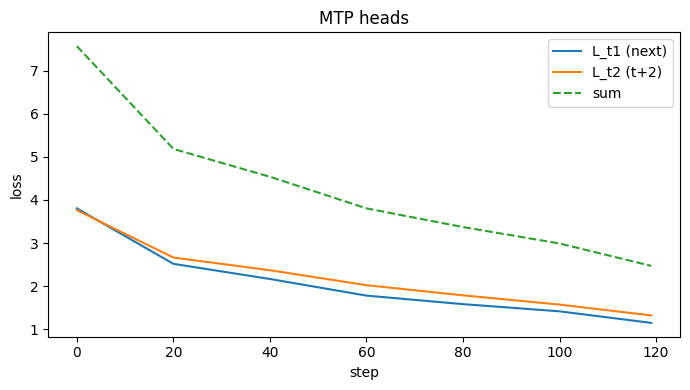

904

In [9]:
cfg_mtp = GPTConfig(vocab_size=V, n_layer=2, n_head=2, n_embd=64, block_size=128,
                    tie_weights=True, use_mtp=True)
mtp = TinyGPT(cfg_mtp).to(device)
data = tok.encode(SAMPLE_TEXT)

def get_batch(bs=8, T=64):
    xs = []
    for _ in range(bs):
        start = random.randint(0, max(0, len(data) - T - 1))
        xs.append(data[start:start + T])
    return torch.tensor(xs, dtype=torch.long, device=device)

opt = torch.optim.AdamW(mtp.parameters(), lr=3e-3)
history = []
mtp.train()
for step in range(120):
    xb = get_batch()
    labels = labels_with_pad_ignored(xb, tok.pad_id)
    o = mtp(xb)
    L = mtp_losses(o["logits_t1"], o["logits_t2"], labels)
    opt.zero_grad(set_to_none=True)
    L["loss_sum"].backward()
    opt.step()
    if step % 20 == 0 or step == 119:
        row = {k: float(L[k].detach()) for k in ("loss_t1", "loss_t2", "loss_sum")}
        row["step"] = step
        history.append(row)
        print(f"step {step:3d}  L_t1={row['loss_t1']:.4f}  L_t2={row['loss_t2']:.4f}  sum={row['loss_sum']:.4f}")

print()
print("What happens: both start near ln(V). Mid-training, L_t1 usually leads L_t2")
print("(next-token is denser; t+2 has more branching uncertainty). Both fall via the")
print("shared trunk. We backprop the sum; we do not feed predicted t+1 into the model.")

try:
    import matplotlib.pyplot as plt
    steps = [h["step"] for h in history]
    plt.figure(figsize=(7, 4))
    plt.plot(steps, [h["loss_t1"] for h in history], label="L_t1 (next)")
    plt.plot(steps, [h["loss_t2"] for h in history], label="L_t2 (t+2)")
    plt.plot(steps, [h["loss_sum"] for h in history], label="sum", linestyle="--")
    plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("MTP heads")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("plot skipped:", e)

Path("artifacts").mkdir(exist_ok=True)
Path("artifacts/notebook_mtp_history.json").write_text(json.dumps(history, indent=2))



## Submission checklist

| Check | Section |
|-------|---------|
| Shapes + dim names | 1.1 |
| Shift with strings | 1.2 |
| Pad mask + count | 1.3 |
| Packed docs + boundary loss | 1.4 |
| PPL ~ V untrained | 1.5 |
| Tied vs untied counts | 1.6 |
| CE vs chunked memory + ratio | 1.7 |
| t+2 head, both losses, train curve | 2 |

CLI twin: `python run_harness.py` writes `artifacts/results.json`.

